Imports

In [ ]:
import torch
import torchvision
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score, MulticlassConfusionMatrix
from torchvision.models import resnet18, ResNet18_Weights
from torch.optim.lr_scheduler import ReduceLROnPlateau
import os

Preprocessing des images

In [ ]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# ── Chargement du dataset EuroSAT ───

dataset_full = torchvision.datasets.EuroSAT(
    root='./data', transform=transform, download=True
)

# split manuel 80/20 — EuroSAT n'a pas de split 

train_size = int(0.8 * len(dataset_full))
test_size  = len(dataset_full) - train_size
dataset_train, dataset_test = random_split(dataset_full, [train_size, test_size])

classes = dataset_full.classes
print(f'Classes : {classes}')
print(f'Train : {len(dataset_train)} images | Test : {len(dataset_test)} images')

Classes : ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Train : 21600 images | Test : 5400 images


Visualisation

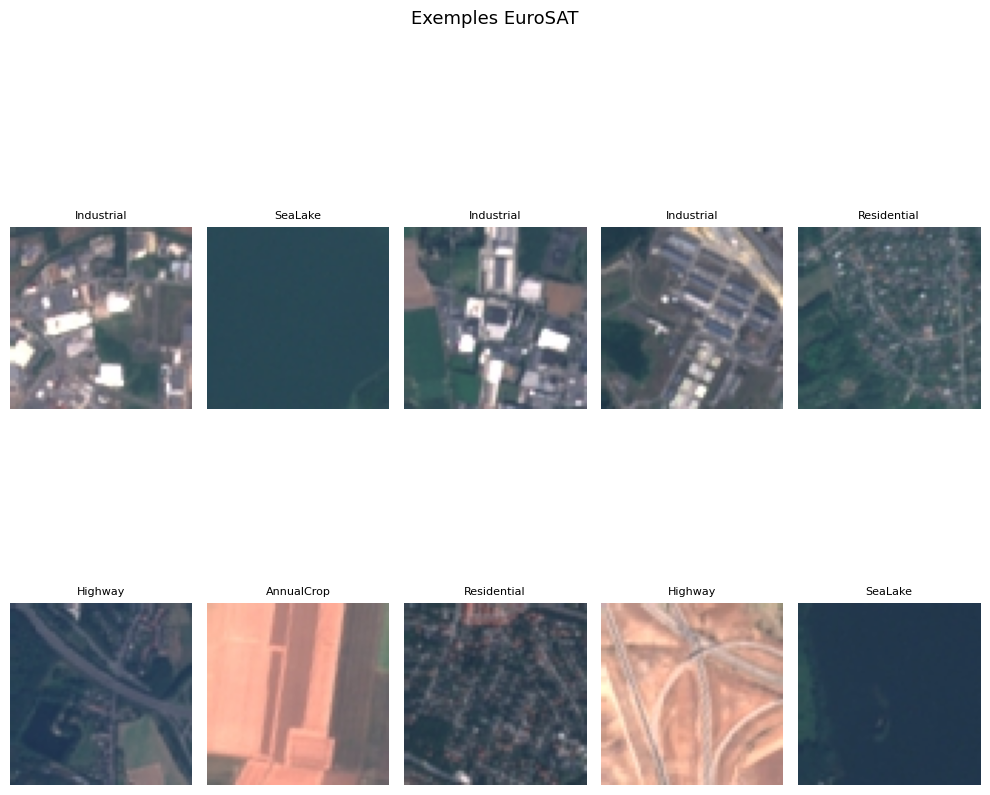

In [ ]:
# ── Visualisation de quelques images du dataset ──

figure = plt.figure(figsize=(10, 10))
cols, rows = 5, 2

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(dataset_train), size=(1,)).item()
    img, label = dataset_train[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(classes[label], fontsize=8)
    plt.axis('off')
    plt.imshow(img.permute(1, 2, 0) * 0.5 + 0.5)

plt.suptitle('Exemples EuroSAT', fontsize=13)
plt.tight_layout()
plt.show()

DataLoader

In [ ]:
# ── Chargement par batch ────

dataloader_train = DataLoader(dataset_train, batch_size=64, shuffle=True)
dataloader_test  = DataLoader(dataset_test,  batch_size=64, shuffle=False)

# vérification
train_features, train_labels = next(iter(dataloader_train))
print(f'Shape batch : {train_features.shape}')

Shape batch : torch.Size([64, 3, 64, 64])


Architecture CNN

In [ ]:
# ── Définition du CNN ─

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(

            # Bloc 1 — extraction de features simples
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                             

            # Bloc 2 — extraction de features complexes
            nn.Conv2d(32, 64, kernel_size=3, padding=1), 
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                            

            # Classifieur
            nn.Flatten(),                                
            nn.Linear(64 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.model(x)

cnn = CNN()
print(cnn)
n_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print(f'Nombre de paramètres : {n_params:,}')

CNN(
  (model): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=16384, out_features=256, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.5, inplace=False)
    (12): Linear(in_features=256, out_features=10, bias=True)
  )
)
Nombre de paramètres : 4,216,714


train_loop et test_loop

In [ ]:
# ── Boucle d'entraînement ───

def train_loop(dataloader, model, criterion, optimizer, writer, epoch):
    model.train()
    loop = tqdm(dataloader, desc='Train')
    for batch, (x, y) in enumerate(loop):
        pred = model(x)
        loss = criterion(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loop.set_postfix(loss=loss.item())
        global_step = epoch * len(dataloader) + batch
        writer.add_scalar('Loss/train', loss.item(), global_step)

# ── Boucle d'évaluation ─
def test_loop(dataloader, model, criterion, writer, epoch):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for x, y in tqdm(dataloader, desc='Test'):
            pred = model(x)
            test_loss += criterion(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    writer.add_scalar('Loss/test', test_loss, epoch)
    writer.add_scalar('Accuracy/test', 100 * correct, epoch)
    print(f'Accuracy : {(100*correct):>0.1f}%, Avg loss : {test_loss:>8f}\n')

In [ ]:
# ── Entraînement du CNN ───
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(cnn.parameters(), lr=0.01)

writer = SummaryWriter('runs/eurosat_cnn')

epochs = 5
for t in range(epochs):
    print(f'Epoch {t+1}\n-------------------------------')
    train_loop(dataloader_train, cnn, criterion, optimizer, writer, t)
    test_loop(dataloader_test,   cnn, criterion, writer, t)

writer.close()

Epoch 1
-------------------------------


Test: 100%|██████████| 85/85 [00:04<00:00, 17.82it/s]


Accuracy : 61.4%, Avg loss : 0.992740

Epoch 2
-------------------------------


Test: 100%|██████████| 85/85 [00:05<00:00, 14.94it/s]


Accuracy : 70.5%, Avg loss : 0.797797

Epoch 3
-------------------------------


...

Accuracy : 78.3%, Avg loss : 0.602935

Epoch 4
-------------------------------


Test: 100%|██████████| 85/85 [00:04<00:00, 17.65it/s]


Accuracy : 66.9%, Avg loss : 1.012842

Epoch 5
-------------------------------


Test: 100%|██████████| 85/85 [00:04<00:00, 18.07it/s]

Accuracy : 63.7%, Avg loss : 1.135146



Transfer Learning ResNet

In [ ]:
model_resnet = resnet18(weights=ResNet18_Weights.DEFAULT)

# on gèle tous les poids — on ne réentraîne pas les couches existantes
for param in model_resnet.parameters():
    param.requires_grad = False
    
# on remplace uniquement la dernière couche pour nos 10 classes
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, 10)

print(model_resnet.fc)
n_params = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
print(f'Paramètres entraînables : {n_params:,}')

Linear(in_features=512, out_features=10, bias=True)
Paramètres entraînables : 5,130


Entraînement ResNet

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_resnet.parameters(), lr=0.01)

writer = SummaryWriter('runs/eurosat_resnet')

epochs = 5
for t in range(epochs):
    print(f'Epoch {t+1}\n-------------------------------')
    train_loop(dataloader_train, model_resnet, criterion, optimizer, writer, t)
    test_loop(dataloader_test,   model_resnet, criterion, writer, t)

writer.close()

Epoch 1
-------------------------------


Test: 100%|██████████| 85/85 [00:18<00:00,  4.61it/s]


Accuracy : 81.6%, Avg loss : 0.624779

Epoch 2
-------------------------------


Test: 100%|██████████| 85/85 [00:19<00:00,  4.47it/s]


Accuracy : 82.9%, Avg loss : 0.541191

Epoch 3
-------------------------------


...

Accuracy : 84.6%, Avg loss : 0.493524

Epoch 4
-------------------------------


Test: 100%|██████████| 85/85 [00:19<00:00,  4.45it/s]


Accuracy : 84.8%, Avg loss : 0.480345

Epoch 5
-------------------------------


Test: 100%|██████████| 85/85 [00:19<00:00,  4.37it/s]

Accuracy : 85.6%, Avg loss : 0.461716



Scheduler et Early Stop

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(cnn.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

writer = SummaryWriter('runs/eurosat_scheduler')

best_loss = float('inf')
patience  = 3
counter   = 0

epochs = 20
for t in range(epochs):
    print(f'Epoch {t+1}\n-------------------------------')
    train_loop(dataloader_train, cnn, criterion, optimizer, writer, t)
    test_loop(dataloader_test,   cnn, criterion, writer, t)

    cnn.eval()
    test_loss = 0
    with torch.no_grad():
        for x, y in dataloader_test:
            pred = cnn(x)
            test_loss += criterion(pred, y).item()
    test_loss /= len(dataloader_test)

    scheduler.step(test_loss)
    print(f'Learning rate : {optimizer.param_groups[0]["lr"]}')

    if test_loss < best_loss:
        best_loss = test_loss
        counter = 0
    else:
        counter += 1
        print(f'Pas d amélioration ({counter}/{patience})')
        if counter >= patience:
            print(f'Early stop à l epoch {t+1}')
            break

writer.close()

Epoch 1
-------------------------------


Test: 100%|██████████| 85/85 [00:04<00:00, 17.49it/s]


Accuracy : 69.1%, Avg loss : 0.926005

Learning rate : 0.01
Epoch 2
-------------------------------


Test: 100%|██████████| 85/85 [00:05<00:00, 16.04it/s]


Accuracy : 60.5%, Avg loss : 1.344661

Learning rate : 0.01
Pas d amélioration (1/3)
Epoch 3
-------------------------------


...

Accuracy : 85.2%, Avg loss : 0.426626

Learning rate : 0.01
Pas d amélioration (1/3)
Epoch 11
-------------------------------


Test: 100%|██████████| 85/85 [00:04<00:00, 18.84it/s]


Accuracy : 86.7%, Avg loss : 0.402125

Learning rate : 0.01
Pas d amélioration (2/3)
Epoch 12
-------------------------------


Test: 100%|██████████| 85/85 [00:04<00:00, 18.17it/s]


Accuracy : 81.9%, Avg loss : 0.587492

Learning rate : 0.005
Pas d amélioration (3/3)
Early stop à l epoch 12


Torchmetrics

Accuracy : 0.8084
F1-macro : 0.8088


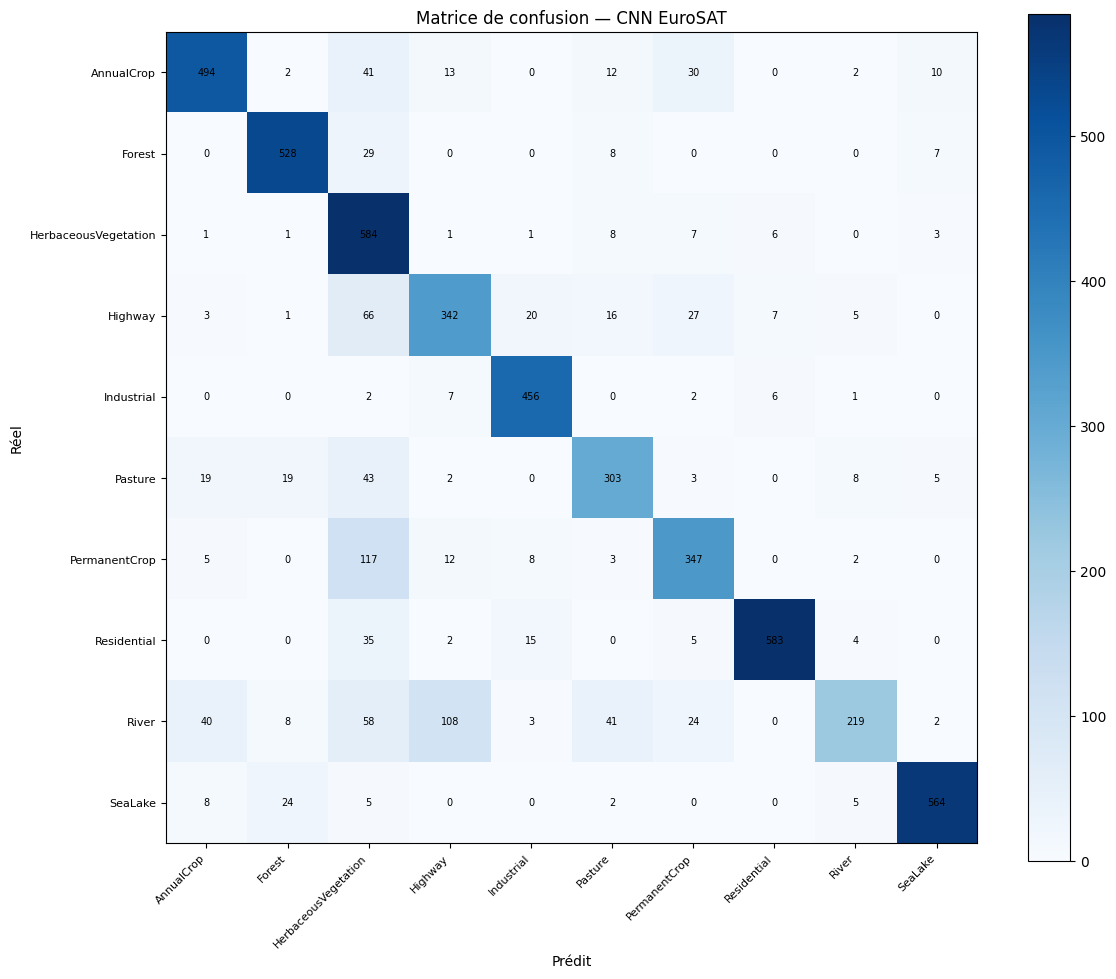

In [ ]:
# ── Évaluation avec Torchmetrics ──
accuracy_metric = MulticlassAccuracy(num_classes=10)
f1_metric       = MulticlassF1Score(num_classes=10, average='macro')
cm_metric       = MulticlassConfusionMatrix(num_classes=10)

cnn.eval()
with torch.no_grad():
    for x, y in dataloader_test:
        pred = cnn(x)
        accuracy_metric.update(pred, y)
        f1_metric.update(pred, y)
        cm_metric.update(pred, y)

acc = accuracy_metric.compute()
f1  = f1_metric.compute()
cm  = cm_metric.compute()

print(f'Accuracy : {acc:.4f}')
print(f'F1-macro : {f1:.4f}')

# ── Matrice de confusion ──
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm.numpy(), cmap='Blues')
plt.colorbar(im)
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(classes, fontsize=8)
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_title('Matrice de confusion — CNN EuroSAT')
for i in range(10):
    for j in range(10):
        ax.text(j, i, int(cm[i, j]), ha='center', va='center', fontsize=7)
plt.tight_layout()
plt.show()

Export ONNX

In [ ]:
import torch.onnx
import os

dummy_input = torch.randn(1, 3, 64, 64)  # une image EuroSAT fictive 64x64

torch.onnx.export(
    cnn,
    dummy_input,
    'cnn_eurosat.onnx',
    input_names=['input'],
    output_names=['output'],
    opset_version=11
)

print('Modèle exporté : cnn_eurosat.onnx')
size_mb = os.path.getsize('cnn_eurosat.onnx') / 1e6
print(f'Taille : {size_mb:.2f} MB')

W0611 10:11:22.871000 1193 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/Users/laly/Sites/A4/IA Analyse prédictive/.venv/lib/python3.13/site-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "/Users/laly/Sites/A4/IA Analyse prédictive/.venv/lib/python3.13/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)

[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Modèle exporté : cnn_eurosat.onnx
Taille : 0.02 MB


In [ ]:
import torch.onnx
import os

dummy_input = torch.randn(1, 3, 64, 64)

torch.onnx.export(
    cnn,
    dummy_input,
    'cnn_eurosat.onnx',
    input_names=['input'],
    output_names=['output'],
    opset_version=11
)

print('Modèle exporté : cnn_eurosat.onnx')
size_mb = os.path.getsize('cnn_eurosat.onnx') / 1e6
print(f'Taille : {size_mb:.2f} MB')

W0611 10:11:23.978000 1193 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX

[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Modèle exporté : cnn_eurosat.onnx
Taille : 0.02 MB


In [ ]:
# ── Prédiction sur 100 images EuroSAT ───

from torchvision.datasets import EuroSAT

dataset_raw = EuroSAT(root='./data', download=False)

correct = 0
total   = 100

for i in tqdm(range(total), desc='Hugging Face'):
    img, label = dataset_raw[i]
    inputs = extractor(images=img, return_tensors='pt')
    with torch.no_grad():
        outputs = model_hf(**inputs)
    pred = outputs.logits.argmax(-1).item()
    if pred == label:
        correct += 1

print(f'Accuracy Hugging Face : {correct / total * 100:.1f}%')

Hugging Face:   0%|          | 0/100 [00:00<?, ?it/s]


NameError: name 'model_hf' is not defined

In [ ]:
# ── Métriques ResNet — comparaison avec le CNN ─


accuracy_metric = MulticlassAccuracy(num_classes=10)
f1_metric       = MulticlassF1Score(num_classes=10, average='macro')

model_resnet.eval()
with torch.no_grad():
    for x, y in dataloader_test:
        pred = model_resnet(x)
        accuracy_metric.update(pred, y)
        f1_metric.update(pred, y)

print(f'ResNet — Accuracy : {accuracy_metric.compute():.4f}')
print(f'ResNet — F1-macro : {f1_metric.compute():.4f}')

ResNet — Accuracy : 0.8499
ResNet — F1-macro : 0.8499
